# Drift Chamber Geant4 Sim Data Analysis

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from mpl_toolkits import mplot3d
import pandas as pd
import random

#%matplotlib widget

In [3]:
events_df = pd.read_csv(f'csv/hits/event_action_data.csv')
events_df['energies_'] = events_df['energies'].str.split('|')
events_df['hitx_'] = events_df['hitx'].str.split('|')
events_df['hity_'] = events_df['hity'].str.split('|')
events_df['hitz_'] = events_df['hitz'].str.split('|')

events_df = events_df.drop(columns=['energies', 'hitx', 'hity', 'hitz'])

In [4]:
def data_for_cylinder(r_outer, r_inner, res, height):
    theta = np.linspace(0, 2 * np.pi, res)
    z = np.linspace(-height, height, res)
    theta_grid, z_grid = np.meshgrid(theta, z)
    
    x_grid = r_outer * np.cos(theta_grid)
    y_grid = r_outer * np.sin(theta_grid)
    
    return x_grid, y_grid, z_grid

Text(0.5, 0, 'hitz [mm]')

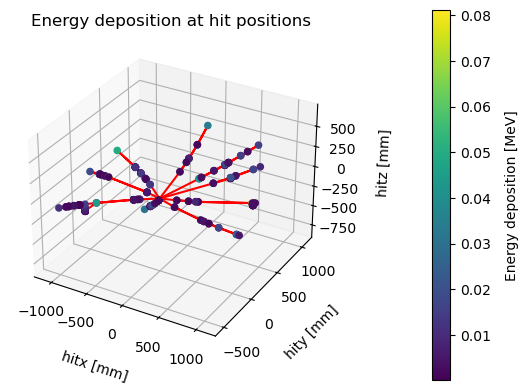

In [9]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

hitx = []
hity = []
hitz = []
energies = []

Xc,Yc,Zc = data_for_cylinder(500, 100, 100, 1000)
#ax.plot_surface(Xc, Yc, Zc, alpha=0.05)

for i in range(len(events_df)):
    cur_row = events_df.loc[i]

    try:
        energies += [float(x) for x in cur_row['energies_'][:-1]]
        x = [float(x) for x in cur_row['hitx_'][:-1]]
        y = [float(x) for x in cur_row['hity_'][:-1]]
        z = [float(x) for x in cur_row['hitz_'][:-1]]
    except:
        continue

    ax.plot3D([0.]+x, [0.]+y, [0.]+z, 'red')

    hitx += x
    hity += y
    hitz += z

img = ax.scatter(hitx, hity, hitz, c=energies, cmap='viridis', alpha=1.0)

cbar = fig.colorbar(img, ax=ax, pad=0.2)
cbar.set_label("Energy deposition [MeV]", labelpad=10)

plt.title("Energy deposition at hit positions")
ax.set_xlabel('hitx [mm]', labelpad=10)
ax.set_ylabel('hity [mm]', labelpad=10)
ax.set_zlabel('hitz [mm]', labelpad=10)